In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import pyro
from pyro.infer.autoguide import AutoLowRankMultivariateNormal
from pyro.infer import Predictive
import pyro.distributions as dist
from pyro.optim import Adam
import random
import pandas as pd
import scipy.io as sio
from sklearn.preprocessing import StandardScaler

# import user-defined files
from utils.Reservoir import Reservoir
from utils.ESNVariational import ESNVariational
from utils.ESNDataset import ESNDataset
from utils.prediction_curve import prediction_curve
from utils.construct_dataset import construct_dataset
from methods_2 import evaluate_metrics


In [2]:
# Load the MAT file
mat_file = sio.loadmat('100307.REST1.LR.SchaeferS.ptseries.mat')
 
print(mat_file.keys())

dict_keys(['__header__', '__version__', '__globals__', 'tseries'])


In [3]:
data = torch.from_numpy(mat_file['tseries']).float()

In [4]:
## PYRO MODEL
# states is a batch of states of size (batch dimension, neurons per state)
def model_fn(states, scale = 0.1, targets=None):
    N_neurons = states.shape[1]
    # We sample the Readout Weights R
    # .to_event(2) ensures Pyro treats this as a matrix, not independent scalars
    R = pyro.sample("R", dist.Normal(torch.zeros(N_neurons, 119), 1.0).to_event(2))
    
    # Linear projection to find the mean load
    mu = (states @ R)
    
    # Observation noise (how much we expect the real data to fluctuate around mu)
    sigma = pyro.sample("sigma", dist.HalfNormal(scale))
    
    with pyro.plate("data", states.shape[0]):
        return pyro.sample("obs", dist.Normal(mu, sigma).to_event(1), obs=targets)

In [5]:
# PARAMETERS

N_NEURONS = 200
INPUT_DIM = data.shape[0] # equals to output dim

LR = 0.01
EPOCHS = 100

# Setup Optimizer
optimizer = pyro.optim.Adam({"lr": LR})

In [6]:
# PYRO GUIDE

RANK = int(np.sqrt(N_NEURONS))  # Rank for the Multivariate Normal
guide = AutoLowRankMultivariateNormal(model_fn, rank=RANK)

In [7]:
# Initialize the ESNVariational
esn_var = ESNVariational(
    N_NEURONS, 
    INPUT_DIM, 
    model_fn, 
    guide, 
    optimizer, 
    spectral_radius=0.9,
    scale = 0.1
)


In [8]:
# Generate Torch datasets
train_ds, valid_ds = construct_dataset(esn_var.reservoir, data.T, train_split=0.7, burnin=100)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

In [9]:
# TRAIN
history = esn_var.train(train_loader, epochs=EPOCHS)

Training Pyro ESN:   1%|          | 1/100 [00:03<06:35,  3.99s/it, Loss=312805.4314]

Epoch 0 | Total ELBO Loss: 312805.4314


Training Pyro ESN: 100%|██████████| 100/100 [00:24<00:00,  4.10it/s, Loss=2256.9529]


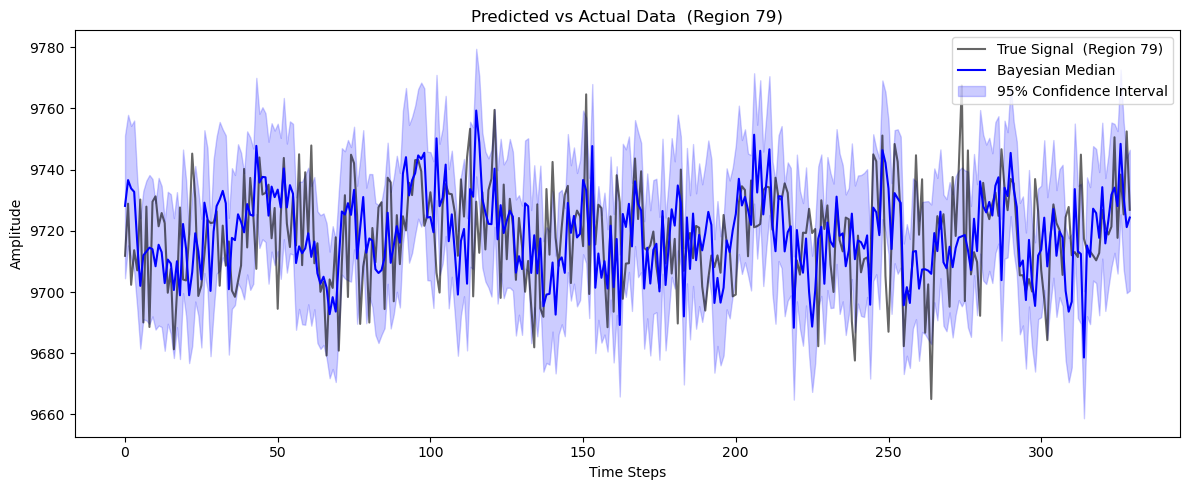

In [10]:
# PREDICT & PLOT
scaler = {'mean': train_ds.mean, 'std': train_ds.std}
y_true, y_samples, y_mean, upper, lower = prediction_curve(esn_var, valid_ds, scaler, region_idx = 79)

In [11]:
ecov, cal, mcrps = evaluate_metrics(y_pred_samples=y_samples, y_true = y_true)

In [12]:
ranges = y_true.max(dim=0).values - y_true.min(dim=0).values
n_mcrps_per_region = mcrps / ranges

In [13]:
n_mcrps_per_region.mean().item() * 100

9.25934836268425

## Random search